In [1]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Decoder, SirenNetUnbatched
from minf.utils import plot_field
from minf.metamol import Metamol
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 32

pdb_file = "../data/6ega_protein.pdb"
sdf_file = "../data/6ega_ligand.sdf"

properties = [
    "wigner_seitz_electron_density",
]

mmol, _ = Metamol.from_complex(pdb_file, sdf_file, size=resolution, properties=properties)

[22:02:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [18]:
mmol.calculate_field()
vector_field = mmol.to_vector_field()[:, :, :, [0, 1, 10, 11, 9, 18]]

yt : [INFO     ] 2025-02-08 22:17:57,170 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 22:17:57,171 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-08 22:17:57,171 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 22:17:57,171 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 22:17:57,171 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 22:17:57,211 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 22:17:57,217 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 22:17:57,218 Creating volume
yt : [INFO     ] 2025-02-08 22:17:57,233 Creating transfer function
yt : [INFO     ] 2025-02-08 22:17:57,233 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


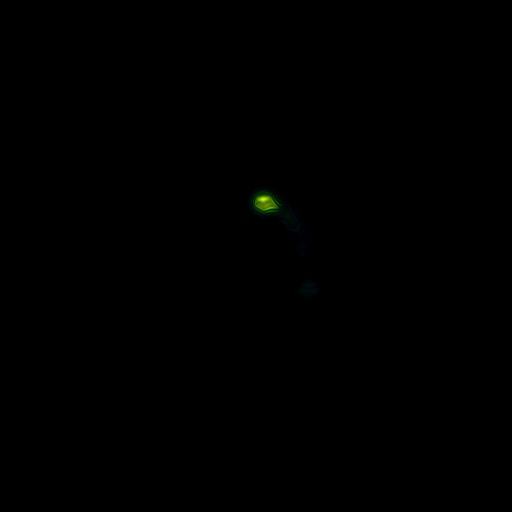

In [19]:
# print(vector_field.shape)
plot_field(vector_field[:, :, :,0])

In [20]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    # output_shape=[resolution, resolution, resolution, 24, 1],
    output_shape=[resolution, resolution, resolution, 6, 1],
    latent_dim=128,
    n_shapes=1
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

In [ ]:
for epoch in (pbar := tqdm(range(2000))):
    loss = decoder(vector_field.cuda(), latent_idx=0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    torch.save(decoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {loss.item()})")

Epoch 977 (loss: 0.017154745757579803):  49%|█████████████████████████████▊                               | 978/2000 [01:54<01:59,  8.55it/s]

yt : [INFO     ] 2025-02-08 22:17:07,041 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 22:17:07,041 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-08 22:17:07,042 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 22:17:07,042 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 22:17:07,042 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 22:17:07,082 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 22:17:07,089 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 22:17:07,089 Creating volume
yt : [INFO     ] 2025-02-08 22:17:07,105 Creating transfer function
yt : [INFO     ] 2025-02-08 22:17:07,106 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


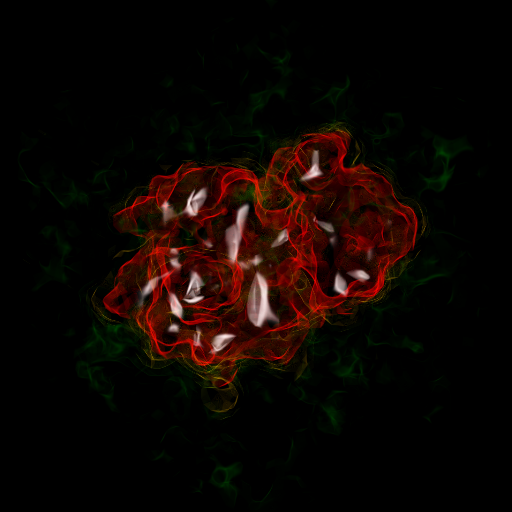

In [17]:
reconstructed = decoder.predict(decoder.latents[0].cuda())
reconstructed = reconstructed.cpu().detach().squeeze(-1)
plot_field(reconstructed[:, :, :, 5])